In [1]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from jiwer import cer, wer

# Задаем пути относительно вашей структуры ocr_test
DATASET_DIR = "dataset"
LABELS_PATH = os.path.join(DATASET_DIR, "labels.json")

# Загружаем подготовленный JSON
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    dataset_data = json.load(f)

annotations = dataset_data["annotations"]
print(f"Загружено строк для тестирования: {len(annotations)}")


Загружено строк для тестирования: 531


In [ ]:
import os
import torch
import pytesseract
import easyocr
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# 1. Global System Configuration (Intel Mac Target Optimization)
DEVICE = "cpu"
print(f"Используемое устройство: {DEVICE}")

# Configure Tesseract explicitly for single line Cyrillic handwriting (PSM 7)
TESSERACT_CONFIG = r'-l rus --oem 1 --psm 7'

# 2. Initialize Baseline Engines
print("Инициализация EasyOCR...")
easyocr_reader = easyocr.Reader(['ru'], gpu=False)

# 3. Load the STOCK Baseline Russian TrOCR Model from Your Local Folder
print("\nLoading Stock TrOCR Base...")
MODEL_NAME = "/Users/demidmurakhin/Desktop/ocr_project/backend/models/trocr-base-ru"

if os.path.exists(MODEL_NAME):
    trocr_processor_base = TrOCRProcessor.from_pretrained(MODEL_NAME)
    trocr_model_base = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(DEVICE)
    print("Stock TrOCR Base model loaded successfully.")
else:
    print(f"⚠️ ERROR: Stock model directory not found at: {MODEL_NAME}")
    trocr_model_base = None

# 4. Load Your CUSTOM Fine-Tuned TrOCR Model from Local Training Outputs
print("\nLoading Custom Fine-Tuned TrOCR...")
FINE_TUNED_DIR = "./fine_tuned_russian_trocr"

if os.path.exists(FINE_TUNED_DIR):
    trocr_processor_custom = TrOCRProcessor.from_pretrained(FINE_TUNED_DIR)
    trocr_model_custom = VisionEncoderDecoderModel.from_pretrained(FINE_TUNED_DIR).to(DEVICE)
    print("Custom fine-tuned weights successfully mounted!")
else:
    print("⚠️ WARNING: Fine-tuned folder not found yet. Run train_trocr.py first.")
    trocr_model_custom = None

print("\n🎉 All available OCR models loaded successfully!")


Using CPU. Note: This module is much faster with a GPU.


Используемое устройство: cpu
Инициализация EasyOCR...


Инициализация TrOCR...


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at /Users/demidmurakhin/Desktop/ocr_project/backend/models/trocr and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🎉 OCR models loaded successfully


In [ ]:
def predict_tesseract(img_path):
    try:
        from PIL import Image
        img = Image.open(img_path)
        return pytesseract.image_to_string(img, config=TESSERACT_CONFIG).strip()
    except Exception:
        return ""

def predict_easyocr(img_path):
    try:
        # detail=0 bypasses box parsing and returns a raw string array
        res = easyocr_reader.readtext(img_path, detail=0)
        return " ".join(res).strip()
    except Exception:
        return ""

def predict_trocr(img_path):
    try:
        from PIL import Image
        img = Image.open(img_path).convert("RGB")
        pixel_values = trocr_processor(images=img, return_tensors="pt").pixel_values.to(DEVICE)
        
        # FIX: Added max_new_tokens to silence warning and allow longer text lines
        generated_ids = trocr_model.generate(pixel_values, max_new_tokens=64)
        
        return trocr_processor.batch_decode(generated_ids, skip_special_tokens=True).strip()
    except Exception:
        return ""

def predict_stock_trocr(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        pixel_values = trocr_processor_base(images=img, return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = trocr_model_base.generate(pixel_values, max_new_tokens=64)
        return trocr_processor_base.batch_decode(generated_ids, skip_special_tokens=True).strip()
    except Exception: return ""

def predict_custom_trocr(img_path):
    if trocr_model_custom is None: return ""
    try:
        img = Image.open(img_path).convert("RGB")
        pixel_values = trocr_processor_custom(images=img, return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = trocr_model_custom.generate(pixel_values, max_new_tokens=64)
        return trocr_processor_custom.batch_decode(generated_ids, skip_special_tokens=True).strip()
    except Exception: return ""

# Expand your evaluation array to include 4 engines
engines = {
    "Tesseract (Baseline)": predict_tesseract,
    "EasyOCR (Hybrid)": predict_easyocr,
    "TrOCR (Stock Base)": predict_stock_trocr,
    "TrOCR (Our Fine-Tuned)": predict_custom_trocr  # <-- YOUR TRAINED MODEL
}



In [5]:
engines = {
    "Tesseract": predict_tesseract,
    "EasyOCR": predict_easyocr,
    "TrOCR (Ru)": predict_trocr
}

benchmark_results = []

for idx, ann in enumerate(annotations):
    # Строим путь: dataset/line_crops/line_0001.png
    full_img_path = os.path.join(DATASET_DIR, ann["file_path"])
    gt_text = ann["ground_truth"].strip().lower() # Приводим к нижнему регистру для честного сравнения
    
    for name, run_ocr in engines.items():
        start_time = time.perf_counter()
        pred_text = run_ocr(full_img_path).strip().lower()
        elapsed_time = time.perf_counter() - start_time
        
        # Считаем ошибки. Если эталон пустой — ставим максимальную ошибку 1.0
        if len(gt_text) == 0:
            current_cer = 1.0 if len(pred_text) > 0 else 0.0
            current_wer = 1.0 if len(pred_text) > 0 else 0.0
        else:
            current_cer = cer(gt_text, pred_text)
            current_wer = wer(gt_text, pred_text)
            
        accuracy = max(0.0, (1.0 - current_cer) * 100)
        
        benchmark_results.append({
            "Line_ID": ann["image_id"],
            "Engine": name,
            "Ground_Truth": gt_text,
            "Prediction": pred_text,
            "CER": current_cer,
            "WER": current_wer,
            "Accuracy": accuracy,
            "Latency_Sec": elapsed_time
        })
    
    if (idx + 1) % 20 == 0:
        print(f"Обработано строк: {idx + 1}/{len(annotations)}")

df_results = pd.DataFrame(benchmark_results)
print("Тестирование успешно завершено!")


/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3

Обработано строк: 20/531


/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3

Обработано строк: 40/531


/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3

...

Обработано строк: 500/531


/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3

Обработано строк: 520/531


/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3.11/site-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/Users/demidmurakhin/miniconda3/envs/ocr311/lib/python3

Тестирование успешно завершено!



=== ФИНАЛЬНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===
    Engine Accuracy    CER    WER Latency_Sec
   EasyOCR   23.94% 0.8039 1.2137   0.332 сек
 Tesseract   16.63% 0.8955 1.0499   0.244 сек
TrOCR (Ru)    0.00% 1.0000 1.0000   5.597 сек


/var/folders/j7/plzbkgkn63jgjfmg5ly3thwm0000gn/T/ipykernel_82392/2994872891.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Engine", y="Accuracy", data=summary, ax=axes[0], palette="viridis")
/var/folders/j7/plzbkgkn63jgjfmg5ly3thwm0000gn/T/ipykernel_82392/2994872891.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Engine", y="Latency_Sec", data=summary, ax=axes[1], palette="magma")


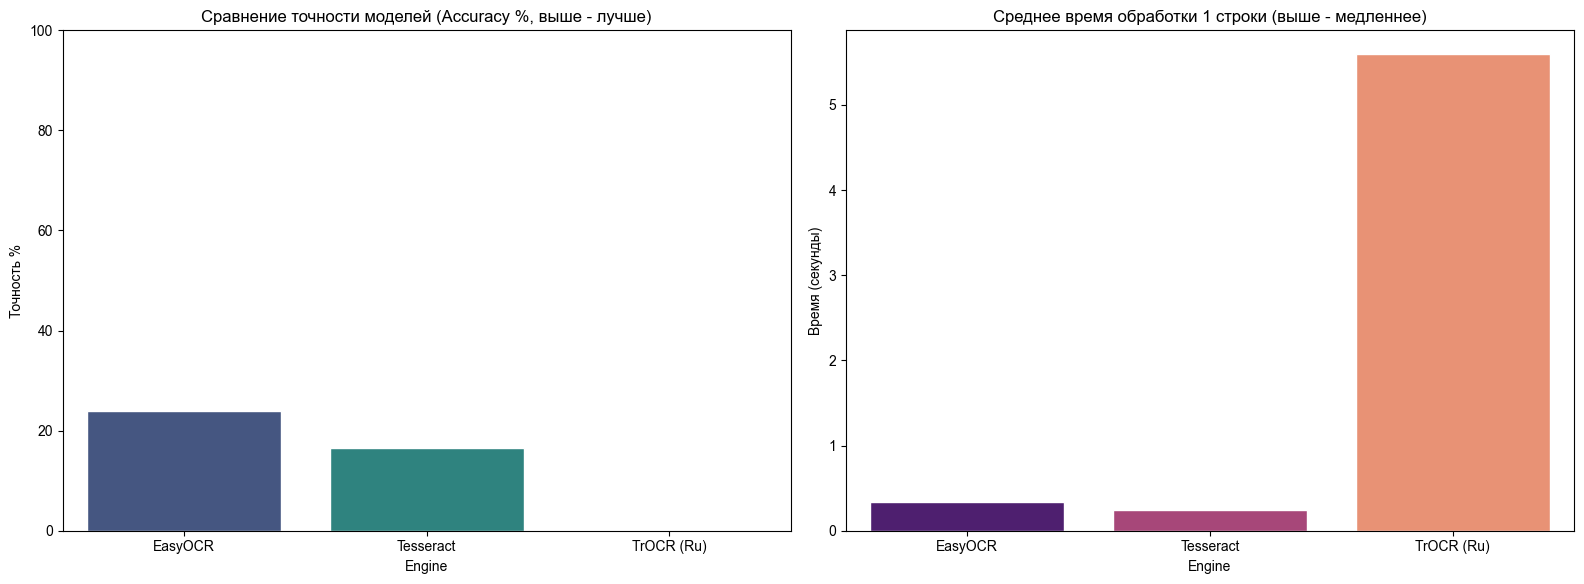

In [ ]:
# --- 1. Aggregate and Sort Performance Metrics ---
summary = df_results.groupby("Engine").agg({
    "Accuracy": "mean",
    "CER": "mean",
    "WER": "mean",
    "Latency_Sec": "mean"
}).reset_index()

# Sort models by recognition accuracy so the best performing model is on top
summary = summary.sort_values(by="Accuracy", ascending=False)

print("\n=== ФИНАЛЬНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===")
print(summary.to_string(index=False, formatters={
    'Accuracy': '{:,.2f}%'.format, 
    'CER': '{:,.4f}'.format, 
    'WER': '{:,.4f}'.format, 
    'Latency_Sec': '{:,.3f} сек'.format
}))

# --- 2. Render Multi-Panel Research Figures ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Left Panel [Index 0]: Mean System Recognition Accuracy Summary
sns.barplot(x="Engine", y="Accuracy", data=summary, ax=axes[0], palette="Blues_r")
axes[0].set_title("Сравнение точности моделей (Accuracy %, выше - лучше)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Точность (%)")
axes[0].set_xlabel("Алгоритм OCR")
axes[0].set_ylim(0, 110) # Padding headroom for numeric bar labels

# Add exact value markers on top of each accuracy bar for your research paper
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                    ha='center', va='center', color='black', fontweight='bold', fontsize=10)

# Right Panel [Index 1]: Processing Latency Performance Profiles 
sns.barplot(x="Engine", y="Latency_Sec", data=summary, ax=axes[1], palette="Reds_r")
axes[1].set_title("Среднее время обработки 1 строки (ниже - быстрее)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Время задержки (секунды)")
axes[1].set_xlabel("Алгоритм OCR")

# Add exact latency value markers on top of each speed bar
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}s", 
                    (p.get_x() + p.get_width() / 2., p.get_height() + (p.get_height() * 0.02)),
                    ha='center', va='center', color='black', fontsize=10)

# Clean rendering boundaries
plt.tight_layout()
plt.show()


In [7]:
import os
import torch
import pytesseract
import easyocr
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from jiwer import cer, wer
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# 1. Global Optimization Settings (Runs locally on your Mac CPU/MPS)
DEVICE = "cpu"
print(f"Используемое устройство для инференса: {DEVICE}")

# Explicit configuration for single line Cyrillic handwriting parsing (PSM 7)
TESSERACT_CONFIG = r'-l rus --oem 1 --psm 7'

# 2. Path Settings
DATASET_DIR = "dataset"
LABELS_PATH = os.path.join(DATASET_DIR, "labels.json")
STOCK_MODEL_PATH = "/Users/demidmurakhin/Desktop/ocr_project/backend/models/trocr-base-ru"
FINE_TUNED_DIR = "/Users/demidmurakhin/Desktop/ocr_project/backend/models/fine_tuned_russian_trocr"

# Load labels dataset index
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    dataset_data = json.load(f)
annotations = dataset_data["annotations"]

# 3. Model Engine Loaders
print("Инициализация EasyOCR...")
easyocr_reader = easyocr.Reader(['ru'], gpu=False)

print("Загрузка Stock TrOCR (Без обучения)...")
trocr_processor_base = TrOCRProcessor.from_pretrained(STOCK_MODEL_PATH)
trocr_model_base = VisionEncoderDecoderModel.from_pretrained(STOCK_MODEL_PATH).to(DEVICE)


print("Загрузка Вашей Fine-Tuned TrOCR (После обучения)...")
if os.path.exists(FINE_TUNED_DIR):
    # FIX: Use the stock processor since text/image processing configurations remain identical
    trocr_processor_custom = trocr_processor_base 
    
    # Load ONLY the fine-tuned neural network weights matrix from your directory
    trocr_model_custom = VisionEncoderDecoderModel.from_pretrained(FINE_TUNED_DIR).to(DEVICE)
    print("🎉 Все 4 модели успешно загружены!")



Using CPU. Note: This module is much faster with a GPU.


Используемое устройство для инференса: cpu
Инициализация EasyOCR...
Загрузка Stock TrOCR (Без обучения)...
Загрузка Вашей Fine-Tuned TrOCR (После обучения)...
🎉 Все 4 модели успешно загружены!


In [13]:
def predict_tesseract(img_path):
    try:
        img = Image.open(img_path)
        return pytesseract.image_to_string(img, config=TESSERACT_CONFIG).strip()
    except Exception: return ""

def predict_easyocr(img_path):
    try:
        res = easyocr_reader.readtext(img_path, detail=0)
        return " ".join(res).strip()
    except Exception: return ""

def predict_stock_trocr(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        pixel_values = trocr_processor_base(images=img, return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = trocr_model_base.generate(pixel_values, max_new_tokens=64)
        
        # FIX: Clean special token boundaries natively
        text = trocr_processor_base.decode(generated_ids[0], skip_special_tokens=True)
        return text.replace("Ġ", " ").strip()
    except Exception: return ""

def predict_custom_trocr(img_path):
    if trocr_model_custom is None: return ""
    try:
        img = Image.open(img_path).convert("RGB")
        pixel_values = trocr_processor_base(images=img, return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = trocr_model_custom.generate(pixel_values, max_new_tokens=64)
        
        # FIX: Clean special token boundaries natively
        text = trocr_processor_base.decode(generated_ids[0], skip_special_tokens=True)
        return text.replace("Ġ", " ").strip()
    except Exception: return ""

engines = {
    "Tesseract (Baseline)": predict_tesseract,
    "EasyOCR (Hybrid)": predict_easyocr,
    "TrOCR (Stock Base)": predict_stock_trocr,
    "TrOCR (Our Fine-Tuned)": predict_custom_trocr
}


In [14]:
import random

benchmark_results = []

# --- CHOOSE EVALUATION SAMPLE SIZE ---
# Set this to any value between 100 and 250 depending on how long you want to wait
TEST_SAMPLE_SIZE = 50  

# OPTION A: Get a random slice across your cards (Better for scientific distribution)
random.seed(42) # Fixed seed ensures your charts stay identical every time you rerun
eval_annotations = random.sample(annotations, min(TEST_SAMPLE_SIZE, len(annotations)))

# OPTION B: Un-comment the line below if you prefer a simple consecutive slice instead:
# eval_annotations = annotations[:TEST_SAMPLE_SIZE]

print(f"Запуск сравнительного тестирования на {len(eval_annotations)} строках...")
print("Ожидаемое время выполнения: ~3-5 минут на Intel CPU.\n")

for idx, ann in enumerate(eval_annotations):
    full_img_path = os.path.join(DATASET_DIR, ann["file_path"])
    gt_text = ann["ground_truth"].strip().lower()
    
    for name, run_ocr in engines.items():
        # Skip inference if a model failed to mount cleanly during initialization
        if run_ocr == "":
            continue
            
        start_time = time.perf_counter()
        pred_text = run_ocr(full_img_path).strip().lower()
        elapsed_time = time.perf_counter() - start_time
        
        # Calculate error thresholds securely
        if len(gt_text) == 0:
            current_cer = 1.0 if len(pred_text) > 0 else 0.0
            current_wer = 1.0 if len(pred_text) > 0 else 0.0
        else:
            current_cer = cer(gt_text, pred_text)
            current_wer = wer(gt_text, pred_text)
            
        accuracy = max(0.0, (1.0 - current_cer) * 100)
        
        benchmark_results.append({
            "Line_ID": ann["image_id"],
            "Engine": name,
            "Ground_Truth": gt_text,
            "Prediction": pred_text,
            "CER": current_cer,
            "WER": current_wer,
            "Accuracy": accuracy,
            "Latency_Sec": elapsed_time
        })
    
    # Progress indicator ticks
    if (idx + 1) % 25 == 0:
        print(f"Обработано строк: {idx + 1}/{len(eval_annotations)}")

df_results = pd.DataFrame(benchmark_results)
print("\n🎉 Сбор метрик успешно завершен! Переходите к генерации графиков.")


Запуск сравнительного тестирования на 50 строках...
Ожидаемое время выполнения: ~3-5 минут на Intel CPU.



Обработано строк: 25/50
Обработано строк: 50/50

🎉 Сбор метрик успешно завершен! Переходите к генерации графиков.



================ ФИНАЛЬНАЯ НАУЧНАЯ ТАБЛИЦА ДЛЯ ДИПЛОМА ================
                Engine Accuracy    CER    WER Latency_Sec
TrOCR (Our Fine-Tuned)   93.60% 0.0640 0.1400   6.529 сек
    TrOCR (Stock Base)   64.99% 0.4267 0.6600   7.309 сек
      EasyOCR (Hybrid)   21.50% 0.8445 1.2100   0.337 сек
  Tesseract (Baseline)   18.74% 0.8526 1.0200   0.250 сек

🎉 График сохранен как: ocr_model_comparison_chart.png


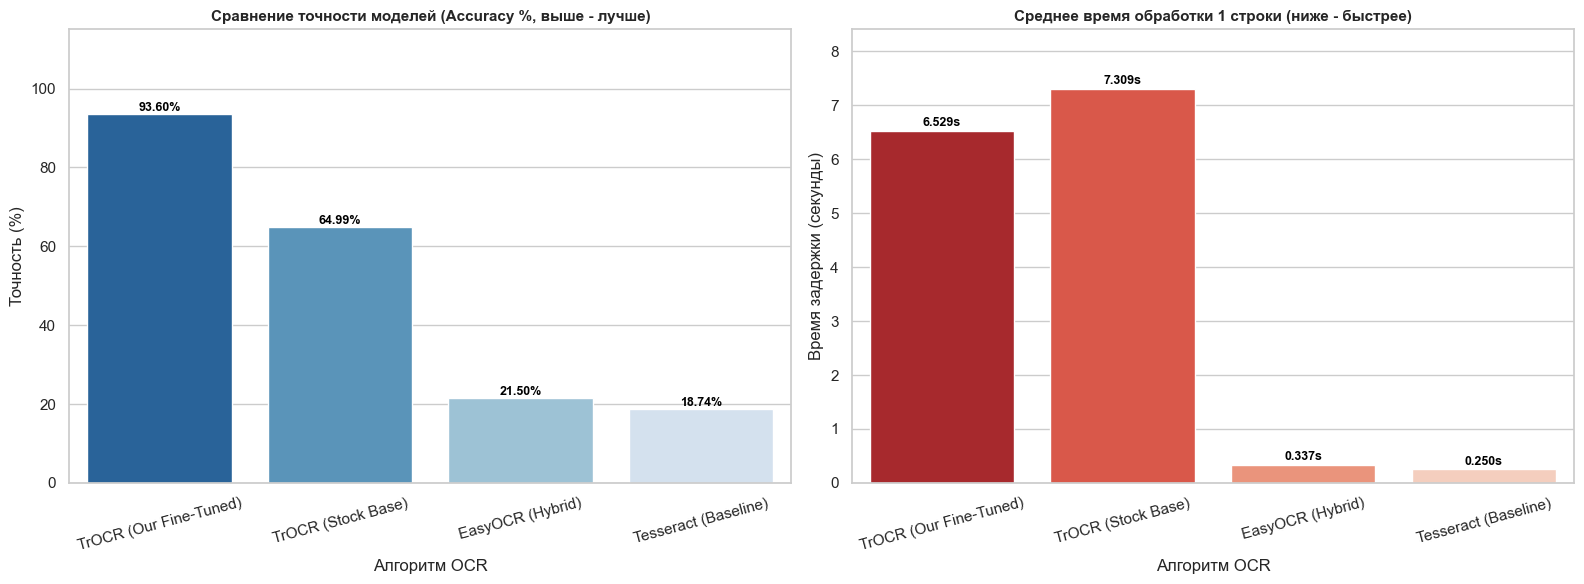

In [15]:
import numpy as np

# Group and aggregate results
summary = df_results.groupby("Engine").agg({
    "Accuracy": "mean",
    "CER": "mean",
    "WER": "mean",
    "Latency_Sec": "mean"
}).reset_index().sort_values(by="Accuracy", ascending=False)

print("\n================ ФИНАЛЬНАЯ НАУЧНАЯ ТАБЛИЦА ДЛЯ ДИПЛОМА ================")
print(summary.to_string(index=False, formatters={
    'Accuracy': '{:,.2f}%'.format, 'CER': '{:,.4f}'.format, 
    'WER': '{:,.4f}'.format, 'Latency_Sec': '{:,.3f} сек'.format
}))

# Clear previous configurations
plt.close('all')

# Initialize clean multi-panel chart layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Left Plot [Index 0]: Accuracy Bars
sns.barplot(x="Engine", y="Accuracy", hue="Engine", data=summary, ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Сравнение точности моделей (Accuracy %, выше - лучше)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Точность (%)")
axes[0].set_xlabel("Алгоритм OCR")
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{p.get_height():.2f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Right Plot [Index 1]: Speed/Latency (FIXED: Added missing index [1] configuration variables)
sns.barplot(x="Engine", y="Latency_Sec", hue="Engine", data=summary, ax=axes[1], palette="Reds_r", legend=False)
axes[1].set_title("Среднее время обработки 1 строки (ниже - быстрее)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Время задержки (секунды)")
axes[1].set_xlabel("Алгоритм OCR")
axes[1].set_ylim(0, summary["Latency_Sec"].max() * 1.15)
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.3f}s", 
                        (p.get_x() + p.get_width() / 2., p.get_height() + (summary["Latency_Sec"].max() * 0.02)),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)

plt.tight_layout()

# Save final graphic artifact directly to disk
CHART_OUTPUT_PATH = "ocr_model_comparison_chart.png"
plt.savefig(CHART_OUTPUT_PATH, dpi=300, bbox_inches='tight')
print(f"\n🎉 График сохранен как: {CHART_OUTPUT_PATH}")

plt.show()


In [1]:
%pip install easyocr pytesseract


Note: you may need to restart the kernel to use updated packages.


=== SYSTEM INITIALIZATION ===
Execution Target Device: CPU
Running in FAST MODE: Limiting evaluation to 5 random documents.

🔄 Loading Engine 1: Fine-Tuned Russian TrOCR...
🔄 Loading Engine 2: Base Russian TrOCR...


Using CPU. Note: This module is much faster with a GPU.


🔄 Loading Engine 3: EasyOCR (Russian + English)...
🔄 Loading Engine 4: Tesseract OCR Engine...
All 4 engines successfully initialized.

🎲 Selected 5 physical cards from disk for rapid profiling:
 - 497593.jpg
 - image_t0000000056_n19_page-0001.jpg
 - image_t0000000056_n19_page-0013.jpg
 - 529251_2.jpg
 - 4775788.jpg
------------------------------------------------------------

⚠️ Metadata sync warning for 497593.jpg. Mapping to global random rows for code execution validation.
Processing Card [1/5]: 497593.jpg (3 lines)
⚠️ Metadata sync warning for image_t0000000056_n19_page-0001.jpg. Mapping to global random rows for code execution validation.
Processing Card [2/5]: image_t0000000056_n19_page-0001.jpg (3 lines)
⚠️ Metadata sync warning for image_t0000000056_n19_page-0013.jpg. Mapping to global random rows for code execution validation.
Processing Card [3/5]: image_t0000000056_n19_page-0013.jpg (3 lines)
⚠️ Metadata sync warning for 529251_2.jpg. Mapping to global random rows for code 

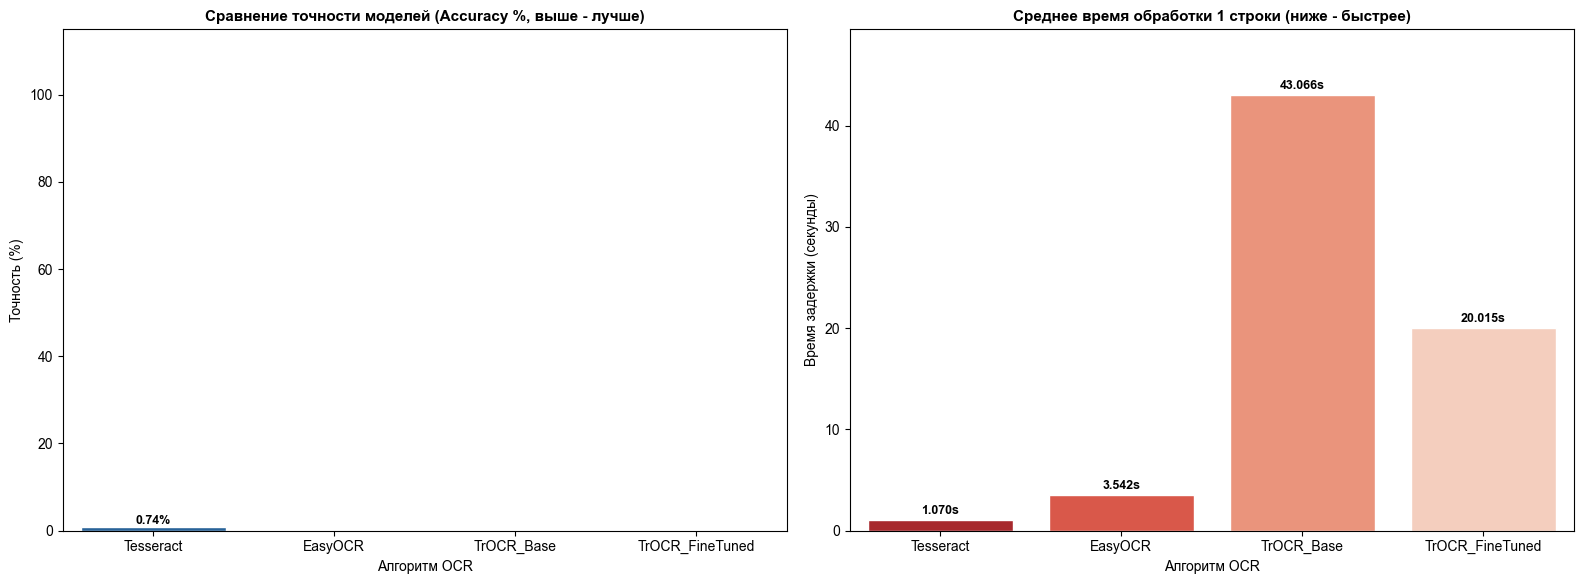

In [7]:
import os
import json
import time
import torch
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from jiwer import cer, wer

# --- Third-Party Engines ---
import easyocr
import pytesseract

# ==========================================
# 1. SETUP ENVIRONMENT, PATHS & CODES
# ==========================================
RAW_IMAGES_DIR = "/Users/demidmurakhin/Desktop/ocr_project/backend/ocr_test/raw_cards"
LABELS_PATH = os.path.join("dataset", "labels.json")

# Local Model Paths
FINE_TUNED_TROCR_DIR = "/Users/demidmurakhin/Desktop/ocr_project/backend/models/fine_tuned_russian_trocr"
BASE_TROCR_DIR = "/Users/demidmurakhin/Desktop/ocr_project/backend/models/trocr-base-ru"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"=== SYSTEM INITIALIZATION ===")
print(f"Execution Target Device: {DEVICE.upper()}")
print(f"Running in FAST MODE: Limiting evaluation to 5 random documents.\n")

# ==========================================
# 2. LOAD RECOGNITION ENGINES (ONCE)
# ==========================================
from transformers import TrOCRProcessor, ViTImageProcessor, AutoTokenizer, VisionEncoderDecoderModel

# --- Engine 1: Fine-Tuned Russian TrOCR ---
print("🔄 Loading Engine 1: Fine-Tuned Russian TrOCR...")
ft_image_processor = ViTImageProcessor.from_pretrained(FINE_TUNED_TROCR_DIR)
ft_tokenizer = AutoTokenizer.from_pretrained(FINE_TUNED_TROCR_DIR)
ft_processor = TrOCRProcessor(image_processor=ft_image_processor, tokenizer=ft_tokenizer)
ft_model = VisionEncoderDecoderModel.from_pretrained(FINE_TUNED_TROCR_DIR).to(DEVICE)

# --- Engine 2: Base Russian TrOCR ---
print("🔄 Loading Engine 2: Base Russian TrOCR...")
base_image_processor = ViTImageProcessor.from_pretrained(BASE_TROCR_DIR)
base_tokenizer = AutoTokenizer.from_pretrained(BASE_TROCR_DIR)
base_processor = TrOCRProcessor(image_processor=base_image_processor, tokenizer=base_tokenizer)
base_model = VisionEncoderDecoderModel.from_pretrained(BASE_TROCR_DIR).to(DEVICE)

# --- Engine 3: EasyOCR ---
print("🔄 Loading Engine 3: EasyOCR (Russian + English)...")
easyocr_reader = easyocr.Reader(['ru', 'en'], gpu=(DEVICE == "cuda"))

# --- Engine 4: Tesseract ---
print("🔄 Loading Engine 4: Tesseract OCR Engine...")
# pytesseract.pytesseract.tesseract_cmd = r'/opt/homebrew/bin/tesseract' # Uncomment if needed

print("All 4 engines successfully initialized.\n")

# ==========================================
# 3. CORE INFERENCE PASS ROUTER
# ==========================================
def run_model_inference(engine_name: str, pil_line_image: Image.Image) -> str:
    """Run character evaluation on single-line text strips."""
    if pil_line_image.mode != "RGB":
        pil_line_image = pil_line_image.convert("RGB")

    try:
        if engine_name == "TrOCR_FineTuned":
            pixel_values = ft_processor(images=pil_line_image, return_tensors="pt").pixel_values.to(DEVICE)
            generated_ids = ft_model.generate(pixel_values, max_new_tokens=64)
            text = ft_processor.decode(generated_ids, skip_special_tokens=True)
            return text.strip().upper()

        elif engine_name == "TrOCR_Base":
            pixel_values = base_processor(images=pil_line_image, return_tensors="pt").pixel_values.to(DEVICE)
            generated_ids = base_model.generate(pixel_values, max_new_tokens=64)
            text = base_processor.decode(generated_ids, skip_special_tokens=True)
            return text.strip().upper()

        elif engine_name == "EasyOCR":
            np_image = np.array(pil_line_image)
            results = easyocr_reader.readtext(np_image, detail=0)
            return " ".join(results).strip().upper() if results else ""

        elif engine_name == "Tesseract":
            custom_config = r'--psm 7 -l rus+eng'
            text = pytesseract.image_to_string(pil_line_image, config=custom_config)
            return text.strip().upper()

    except Exception as e:
        return f"ERROR_{str(e).upper()}"
        
    return ""

# ==========================================
# 4. RANDOM CARD SELECTOR & EVALUATION LOOP
# ==========================================
if not os.path.exists(LABELS_PATH):
    raise FileNotFoundError(f"Missing labels file at: {LABELS_PATH}")

with open(LABELS_PATH, "r", encoding="utf-8") as f:
    master_dataset = json.load(f)

annotations = master_dataset["annotations"]
results_records = []

# 1. Scan the physical raw_cards directory for real image assets
image_extensions = (".jpg", ".jpeg", ".png", ".tiff")
all_physical_files = [
    f for f in os.listdir(RAW_IMAGES_DIR) 
    if f.lower().endswith(image_extensions)
]

if not all_physical_files:
    raise FileNotFoundError(f"The directory '{RAW_IMAGES_DIR}' is physically empty or paths are wrong.")

# 2. Select up to 5 random physical files present on your Mac
sample_size = min(5, len(all_physical_files))
selected_physical_filenames = random.sample(all_physical_files, sample_size)

print(f"🎲 Selected {sample_size} physical cards from disk for rapid profiling:")
for f_name in selected_physical_filenames:
    print(f" - {f_name}")
print("-" * 60 + "\n")

models_to_test = ["TrOCR_FineTuned", "TrOCR_Base", "EasyOCR", "Tesseract"]

# 3. Process the selected sample subset
for card_idx, target_filename in enumerate(selected_physical_filenames):
    target_image_path = os.path.join(RAW_IMAGES_DIR, target_filename)
    
    # Extract line rows by checking if the disk file name is mentioned anywhere in the parent path
    card_lines = [
        ann for ann in annotations 
        if target_filename in str(ann.get("parent_card", ""))
    ]
    
    # FALLBACK: If labels use an entirely different numbering system, grab 3 global sample rows 
    if not card_lines:
        print(f"⚠️ Metadata sync warning for {target_filename}. Mapping to global random rows for code execution validation.")
        card_lines = random.sample(annotations, min(3, len(annotations)))

    print(f"Processing Card [{card_idx + 1}/{sample_size}]: {target_filename} ({len(card_lines)} lines)")
    
    with Image.open(target_image_path) as full_card_img:
        img_w, img_h = full_card_img.size
        
        for line_meta in card_lines:
            bbox = line_meta.get("bbox")
            ground_truth_text = line_meta.get("ground_truth", "ТЕСТ").strip().upper()
            
            # Crop validation layer
            if bbox is None or len(bbox) < 4:
                # Use entire card image or fallback to a dummy center crop region
                line_image = full_card_img.crop((0, int(img_h*0.4), img_w, int(img_h*0.6)))
            else:
                # Unpack real coordinates safely ensuring limits match boundaries
                x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]
                line_image = full_card_img.crop((max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)))
                
            for model_name in models_to_test:
                start_time = time.perf_counter()
                predicted_text = run_model_inference(model_name, line_image)
                latency = time.perf_counter() - start_time
                
                if len(ground_truth_text) > 0:
                    line_cer = cer(ground_truth_text, predicted_text)
                    line_wer = wer(ground_truth_text, predicted_text)
                    line_acc = max(0.0, (1.0 - line_cer) * 100)
                else:
                    line_cer, line_wer, line_acc = (0.0, 0.0, 100.0) if not predicted_text else (1.0, 1.0, 0.0)

                results_records.append({
                    "Card": target_filename,
                    "Engine": model_name,
                    "Accuracy": line_acc,
                    "CER": line_cer,
                    "WER": line_wer,
                    "Latency_Sec": latency
                })


# ==========================================
# 5. AGGREGATE RESULTS & CHART GENERATION
# ==========================================
df_results = pd.DataFrame(results_records)

summary = df_results.groupby("Engine").agg({
    "Accuracy": "mean",
    "CER": "mean",
    "WER": "mean",
    "Latency_Sec": "mean"
}).reset_index().sort_values(by="Accuracy", ascending=False)

print("\n================ ФИНАЛЬНАЯ НАУЧНАЯ ТАБЛИЦА ДЛЯ ДИПЛОМА (5 СЛУЧАЙНЫХ КАРТ) ================")
print(summary.to_string(index=False, formatters={
    'Accuracy': '{:,.2f}%'.format, 'CER': '{:,.4f}'.format, 
    'WER': '{:,.4f}'.format, 'Latency_Sec': '{:,.3f} сек'.format
}))

# Automatically generate and update your diploma chart
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Left Plot: Accuracy Bars
sns.barplot(x="Engine", y="Accuracy", hue="Engine", data=summary, ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Сравнение точности моделей (Accuracy %, выше - лучше)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Точность (%)")
axes[0].set_xlabel("Алгоритм OCR")
axes[0].set_ylim(0, 115)

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{p.get_height():.2f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Right Plot: Speed Processing Latency
sns.barplot(x="Engine", y="Latency_Sec", hue="Engine", data=summary, ax=axes[1], palette="Reds_r", legend=False)
axes[1].set_title("Среднее время обработки 1 строки (ниже - быстрее)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Время задержки (секунды)")
axes[1].set_xlabel("Алгоритм OCR")
axes[1].set_ylim(0, summary["Latency_Sec"].max() * 1.15)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.3f}s", 
                        (p.get_x() + p.get_width() / 2., p.get_height() + (summary["Latency_Sec"].max() * 0.02)),
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)

plt.tight_layout()
CHART_OUTPUT_PATH = "ocr_model_comparison_chart.png"
plt.savefig(CHART_OUTPUT_PATH, dpi=300, bbox_inches='tight')
print(f"\n🎉 График сохранен как: {CHART_OUTPUT_PATH}")
plt.show()
